In [1]:
##Trying (and failing) to set a seed
# import os
# os.environ["PYTHONHASHSEED"] = "42"
# # cuBLAS determinism (needed for some matmul paths on CUDA). Set *before* torch import.
# # Use one of the two values; 16:8 uses less memory, 4096:8 may be faster.
# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
# import random

In [1]:
import numpy as np
np.set_printoptions(threshold=100000, linewidth=100000)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [2]:
import datetime
def write_csv_file(y_pred :np.ndarray):
    '''Write csv file from numpy array y_pred'''
    now_string = (datetime.datetime.now()-datetime.timedelta(hours=3)).strftime("%d-%m_%H-%M-%S")
    
    output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
    output_df['%'] = y_pred#.squeeze().detach().cpu().numpy()
    output_df.to_csv("time2_trilha1_"+now_string+".csv", sep="\t", index=False)
    return output_df

In [2]:
# def set_seed(seed: int = 42, deterministic: bool = True, first_run=False):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)

#     # cuDNN/cuBLAS determinism
#     if deterministic:
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = False
#         torch.use_deterministic_algorithms(True, warn_only=False)

#     if first_run:
#         torch.set_num_threads(1)
#         torch.set_num_interop_threads(1)
        
# seed = 42
# set_seed(seed, deterministic=True, first_run=True)

In [4]:
train_df = pd.read_csv('data_train_autoDWT_n.csv', sep="\t")
test_df = pd.read_csv('data_test_autoDWT_n.csv', sep="\t")

### Rodando com os primeiros datapoints

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(f"Device is {device}")

n_init_points = 800
X = torch.Tensor(np.array(train_df.iloc[:,:n_init_points])).to(device)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1)).to(device)

trainDs, valDs = random_split(TensorDataset(X, y), [.8,.2])
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

Device is cuda


In [10]:
model = nn.Sequential(
    nn.Linear(n_init_points,256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.060701 | Val MSE: 0.046407
Epoch 10 | Train MSE: 0.026744 | Val MSE: 0.024503
Epoch 20 | Train MSE: 0.014610 | Val MSE: 0.015363
Epoch 30 | Train MSE: 0.013205 | Val MSE: 0.013727
Epoch 40 | Train MSE: 0.012713 | Val MSE: 0.012565
Epoch 50 | Train MSE: 0.014362 | Val MSE: 0.011936
Epoch 60 | Train MSE: 0.011751 | Val MSE: 0.011582
Epoch 70 | Train MSE: 0.011558 | Val MSE: 0.011120
Epoch 80 | Train MSE: 0.014880 | Val MSE: 0.012780
Epoch 90 | Train MSE: 0.011015 | Val MSE: 0.010609


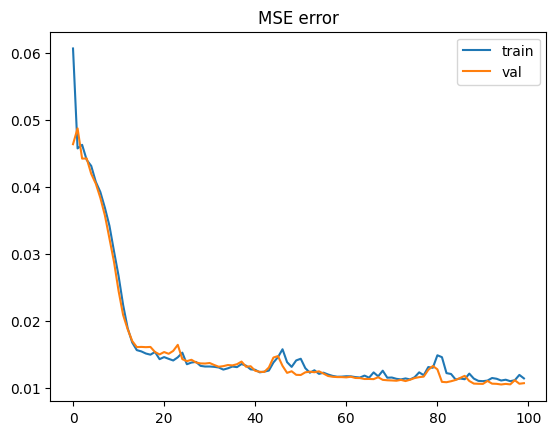

In [11]:
epochs = 100  #20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%10==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.103506714 R²: 0.79754674 MAE: 0.08287672


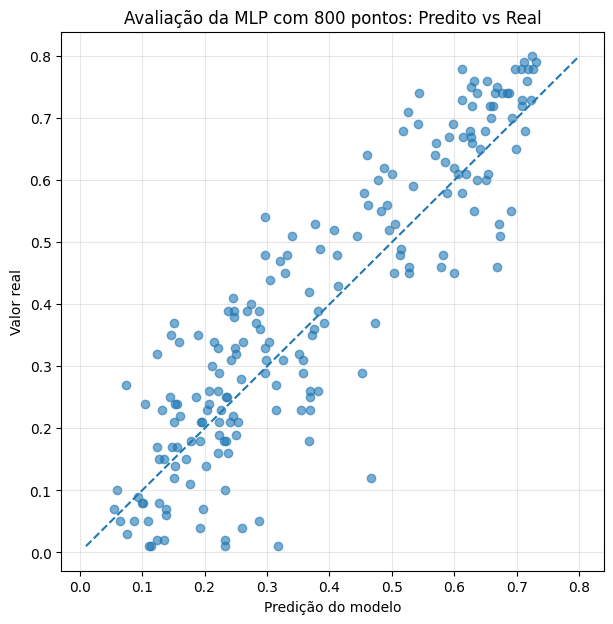

In [12]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title(f"Avaliação da MLP com {n_init_points} pontos: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [209]:
write_csv_file(y_pred.squeeze().detach().cpu().numpy())

,CPMG,%
0,CPMG_000.csv,0.386244
1,CPMG_001.csv,0.694590
2,CPMG_002.csv,0.217418
3,CPMG_003.csv,0.326525
4,CPMG_004.csv,0.102075
...,...,...
995,CPMG_995.csv,0.217330
996,CPMG_996.csv,0.735972
997,CPMG_997.csv,0.179982
998,CPMG_998.csv,0.328672


### Fazendo PCA

In [13]:
train_df = pd.read_csv('data_train_autoDWT_n.csv', sep="\t")
test_df = pd.read_csv('data_test_autoDWT_n.csv', sep="\t")

In [14]:
pca = sklearn.decomposition.PCA(n_components=.999)
pca.fit(train_df.iloc[:,:-1])

,n_components,0.999
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [15]:
train_df_pca = pd.DataFrame(pca.transform(train_df.iloc[:,:-1]))
train_df_pca['y'] = train_df['y']
test_df_pca = pd.DataFrame(pca.transform(test_df))
# train_df_pca.to_csv("data_train_PCA.csv", sep="\t")
# test_df_pca.to_csv("data_test_PCA.csv", sep="\t")
train_df_pca

,0,1,2,3,y
0,0.571469,0.135649,-0.030981,0.007956,0.29
1,0.576832,0.219308,-0.001929,-0.015690,0.30
2,0.913936,0.168125,-0.024875,-0.022108,0.11
3,-0.977060,-0.039318,-0.023731,-0.008363,0.61
4,-1.281197,-0.204547,-0.046584,-0.037823,0.74
...,...,...,...,...,...
995,0.050160,0.015137,0.006587,-0.010807,0.33
996,-0.436195,0.136117,-0.006359,0.012897,0.29
997,-0.372477,-0.282153,0.014950,-0.059421,0.36
998,-0.817202,0.006076,-0.009622,0.002112,0.69


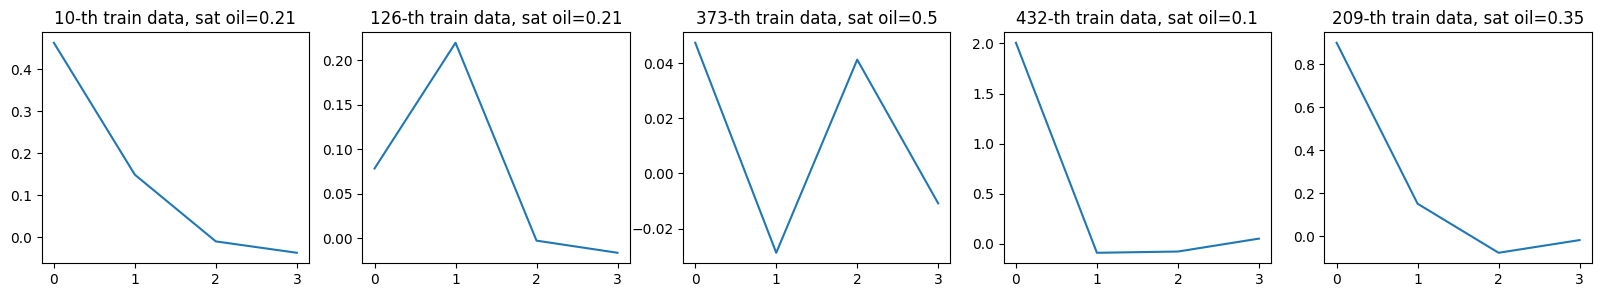

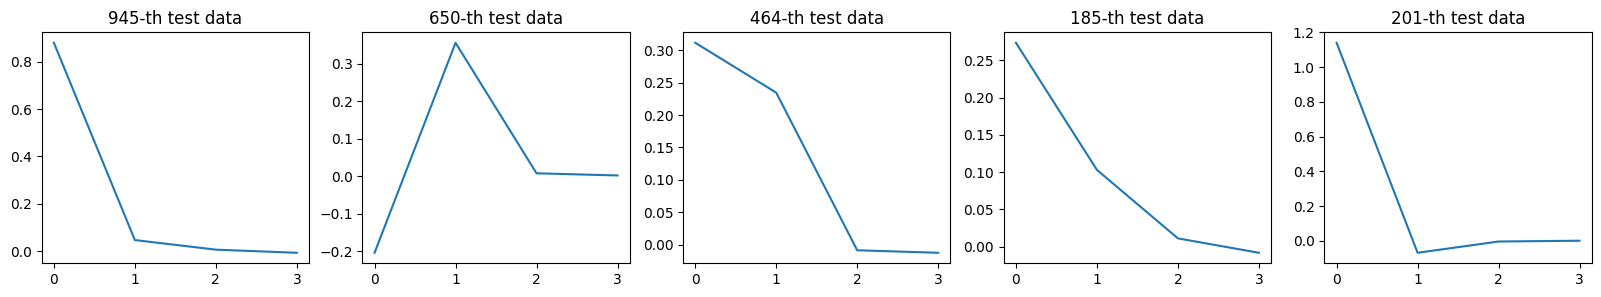

In [16]:
'''Plot graph of test and train after PCA'''
# set_seed(seed)
fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(train_df_pca.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th train data, sat oil={train_df_pca.iloc[j,-1]}")
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(test_df_pca.loc[j].values)
    ax[i].set_title(f"{j}-th test data")
plt.show();

In [24]:
# set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(train_df_pca.iloc[:,:-1])).to(device)
y = torch.Tensor(np.array(train_df_pca['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)

Device is cuda


In [19]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    # nn.ReLU(),
    # nn.Linear(128,32),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.052237 | Val MSE: 0.048403
Epoch 05 | Train MSE: 0.036664 | Val MSE: 0.034308
Epoch 10 | Train MSE: 0.016546 | Val MSE: 0.017441
Epoch 15 | Train MSE: 0.014753 | Val MSE: 0.016037
Epoch 20 | Train MSE: 0.014185 | Val MSE: 0.013994
Epoch 25 | Train MSE: 0.013379 | Val MSE: 0.013677
Epoch 30 | Train MSE: 0.012998 | Val MSE: 0.013356
Epoch 35 | Train MSE: 0.012785 | Val MSE: 0.013620
Epoch 40 | Train MSE: 0.012835 | Val MSE: 0.013249
Epoch 45 | Train MSE: 0.012041 | Val MSE: 0.011519
Epoch 50 | Train MSE: 0.013959 | Val MSE: 0.014561
Epoch 55 | Train MSE: 0.011296 | Val MSE: 0.011007
Epoch 60 | Train MSE: 0.012421 | Val MSE: 0.011741
Epoch 65 | Train MSE: 0.012022 | Val MSE: 0.011339
Epoch 70 | Train MSE: 0.011170 | Val MSE: 0.010555
Epoch 75 | Train MSE: 0.011351 | Val MSE: 0.010942
Epoch 80 | Train MSE: 0.011286 | Val MSE: 0.011389
Epoch 85 | Train MSE: 0.010891 | Val MSE: 0.010402
Epoch 90 | Train MSE: 0.011105 | Val MSE: 0.010641
Epoch 95 | Train MSE: 0.011186 

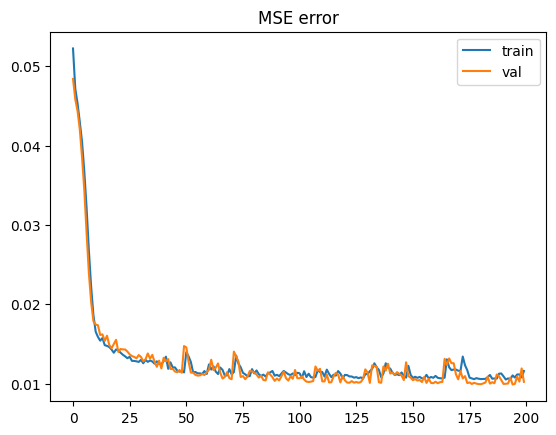

RMSE: 0.101124205 R²: 0.8067596 MAE: 0.0781277


In [20]:
# set_seed(seed)
epochs = 200
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

In [39]:
Xtest = torch.Tensor(np.array(test_df_pca)).to(device)
model.eval()
with torch.no_grad():
    ytest_pred = model(Xtest).squeeze().detach().cpu().numpy()

write_csv_file(ytest_pred)

,CPMG,%
0,CPMG_000.csv,0.256301
1,CPMG_001.csv,0.633611
2,CPMG_002.csv,0.106491
3,CPMG_003.csv,0.219805
4,CPMG_004.csv,0.108862
...,...,...
995,CPMG_995.csv,0.137903
996,CPMG_996.csv,0.693103
997,CPMG_997.csv,0.106289
998,CPMG_998.csv,0.140850


Epoch 00 | Train MSE: 0.057504 | Val MSE: 0.038221
Epoch 05 | Train MSE: 0.013343 | Val MSE: 0.010150
Epoch 10 | Train MSE: 0.010598 | Val MSE: 0.009391
Epoch 15 | Train MSE: 0.009169 | Val MSE: 0.007706
Epoch 20 | Train MSE: 0.008455 | Val MSE: 0.007037
Epoch 25 | Train MSE: 0.008179 | Val MSE: 0.006978
Epoch 30 | Train MSE: 0.008041 | Val MSE: 0.006485
Epoch 35 | Train MSE: 0.008019 | Val MSE: 0.006644
Epoch 40 | Train MSE: 0.008130 | Val MSE: 0.006418
Epoch 45 | Train MSE: 0.007960 | Val MSE: 0.006439
Epoch 50 | Train MSE: 0.007913 | Val MSE: 0.006700
Epoch 55 | Train MSE: 0.007920 | Val MSE: 0.006330
Epoch 60 | Train MSE: 0.007953 | Val MSE: 0.006452
Epoch 65 | Train MSE: 0.008019 | Val MSE: 0.006461
Epoch 70 | Train MSE: 0.008117 | Val MSE: 0.006340


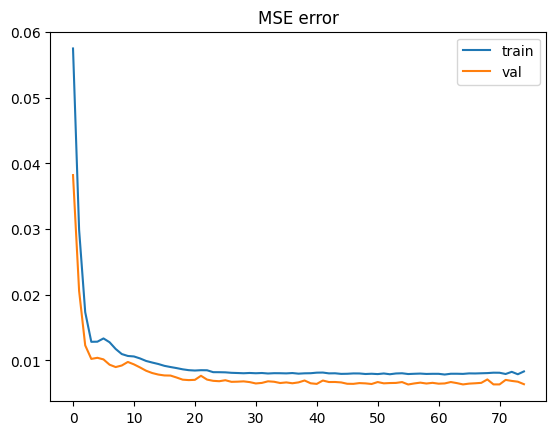

In [122]:
epochs = 75
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.07982877 R²: 0.8863217 MAE: 0.06206659


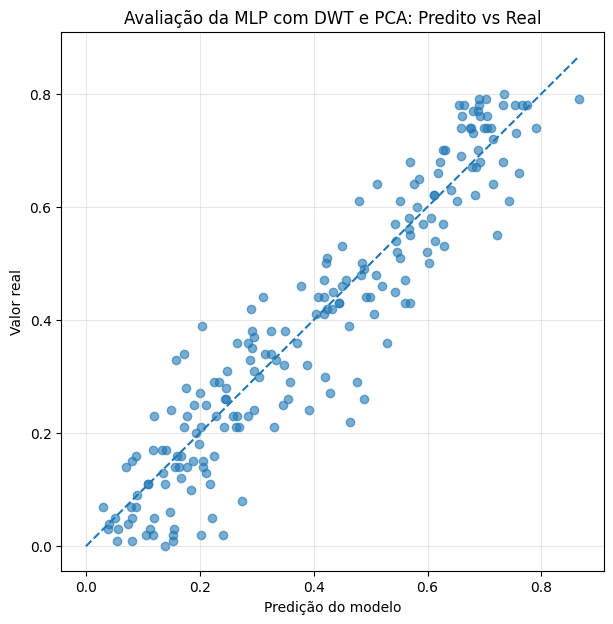

In [130]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da MLP com DWT e PCA: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

Agora com CatBoost

In [51]:
%pip install catboost

  Using cached catboost-1.2.8-cp310-cp310-manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.4.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached narwhals-2.11.0-py3-none-any.whl.metadata (11 kB)
Using cached catboost-1.2.8-cp310-cp310-manylinux2014_x86_64.whl (99.2 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached plotly-6.4.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.11.0-py3-none-any.whl (423 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]3/4 [catboost]
Note: you may need to restart the kernel to use updated packages.


## Catboost: training setup

In [21]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

n_init_points = 500
X = np.array(train_df.iloc[:,:n_init_points])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

model = CatBoostRegressor()
model.fit(Xtrain,ytrain, verbose=0, eval_set=(Xval,yval))

[(1000, 500), (1000,), (800, 500), (200, 500), (800,), (200,)]


RMSE: 0.10535623904292296 R²: 0.7803730532182944 MAE: 0.08320179343656879


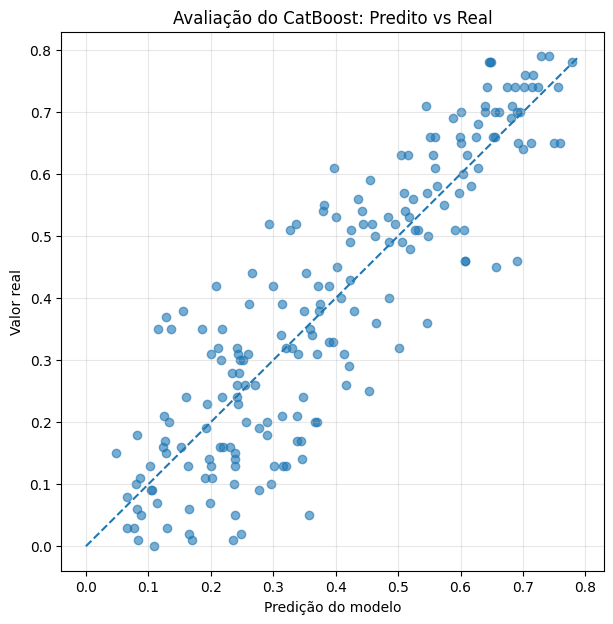

In [22]:
y_pred = model.predict(Xval)

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação do CatBoost: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [196]:
Xtest = np.array(short_test_df.iloc[:,:n_init_points])
write_csv_file(model.predict(Xtest))

,CPMG,%
0,CPMG_000.csv,0.274665
1,CPMG_001.csv,0.669553
2,CPMG_002.csv,0.183837
3,CPMG_003.csv,0.434456
4,CPMG_004.csv,0.072703
...,...,...
995,CPMG_995.csv,0.242696
996,CPMG_996.csv,0.748017
997,CPMG_997.csv,0.209394
998,CPMG_998.csv,0.225531


## Agora uma CNN, por favor

In [24]:
train_df = pd.read_csv('data_train_autoDWT_n.csv', sep="\t")
test_df = pd.read_csv('data_test_autoDWT_n.csv', sep="\t")

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_init_points = 800
X = torch.Tensor(np.array(train_df)[:,:800]).unsqueeze(1).to(device)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [38]:
model = nn.Sequential(
    nn.Conv1d(1,4,5),
    nn.ReLU(),
    nn.MaxPool1d(4),

    nn.Conv1d(4,16,5),
    nn.ReLU(),
    nn.MaxPool1d(4),

    nn.Conv1d(16,4,5),
    nn.ReLU(),
    nn.MaxPool1d(4),
    
    nn.Flatten(),
    nn.Linear(44,64),
    nn.ReLU(),

    nn.Linear(64,16),
    nn.ReLU(),
        
    nn.Linear(16,1),
    nn.Sigmoid()
).to(device)

#to get the size right in the linear layer
# x = torch.randn(1000, 1, 2201)
# out = model(X)
# print(out.shape)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 04 | Train MSE: 0.065313 | Val MSE: 0.069666
Epoch 09 | Train MSE: 0.054973 | Val MSE: 0.057082
Epoch 14 | Train MSE: 0.051814 | Val MSE: 0.054605
Epoch 19 | Train MSE: 0.051372 | Val MSE: 0.054010
Epoch 24 | Train MSE: 0.050740 | Val MSE: 0.053729
Epoch 29 | Train MSE: 0.048803 | Val MSE: 0.050630
Epoch 34 | Train MSE: 0.045019 | Val MSE: 0.046225
Epoch 39 | Train MSE: 0.038409 | Val MSE: 0.038314
Epoch 44 | Train MSE: 0.025444 | Val MSE: 0.023490
Epoch 49 | Train MSE: 0.014019 | Val MSE: 0.016790
Epoch 54 | Train MSE: 0.013176 | Val MSE: 0.012511
Epoch 59 | Train MSE: 0.012767 | Val MSE: 0.011475
Epoch 64 | Train MSE: 0.012727 | Val MSE: 0.011260
Epoch 69 | Train MSE: 0.012528 | Val MSE: 0.011081
Epoch 74 | Train MSE: 0.012344 | Val MSE: 0.010771
Epoch 79 | Train MSE: 0.012130 | Val MSE: 0.010676
Epoch 84 | Train MSE: 0.012050 | Val MSE: 0.010504
Epoch 89 | Train MSE: 0.012386 | Val MSE: 0.011951
Epoch 94 | Train MSE: 0.012094 | Val MSE: 0.010834
Epoch 99 | Train MSE: 0.012320 

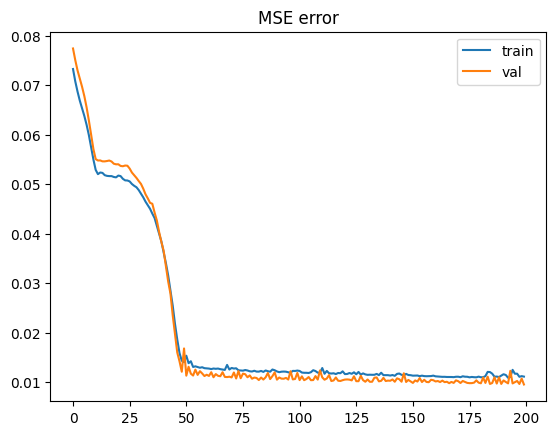

In [39]:
epochs = 200
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if (epoch+1)%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.09751217 R²: 0.8270851 MAE: 0.07839134


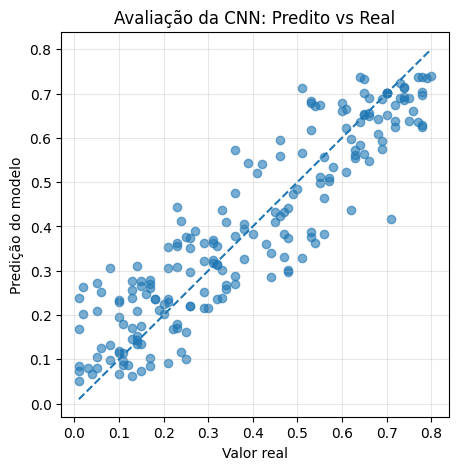

In [40]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()
# print(Xval.shape, yval.shape)

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Valor real")
plt.ylabel("Predição do modelo")
plt.title("Avaliação da CNN: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
Xtest = torch.Tensor(np.array(test_df)[:,:800]).unsqueeze(1).to(device)

model.eval()
with torch.no_grad():
    ytest_pred = model(Xtest).squeeze().detach().cpu().numpy()

write_csv_file(ytest_pred)

,CPMG,%
0,CPMG_000.csv,0.270993
1,CPMG_001.csv,0.700813
2,CPMG_002.csv,0.159076
3,CPMG_003.csv,0.381976
4,CPMG_004.csv,0.090179
...,...,...
995,CPMG_995.csv,0.274668
996,CPMG_996.csv,0.715862
997,CPMG_997.csv,0.214630
998,CPMG_998.csv,0.220771


## RNN: GRU

In [79]:
train_df = pd.read_csv('data_train_DWT.csv', sep="\t")
test_df = pd.read_csv('data_test_DWT.csv', sep="\t")

In [80]:
X = torch.Tensor(np.array(train_df)[:,:-1]).unsqueeze(2)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1))

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
X.shape

torch.Size([1000, 2202, 1])

In [81]:
hidden_size = 16
gru = nn.GRU(input_size=1, hidden_size=hidden_size, num_layers=2, batch_first=True)
head = nn.Linear(hidden_size, 1)   # prediction head

# combine params from both "submodules"
optimizer = torch.optim.Adam(list(gru.parameters()) + list(head.parameters()), lr=1e-3)
criterion = nn.MSELoss()

epoch 01 | train MSE: 0.065550
epoch 02 | train MSE: 0.061722
epoch 03 | train MSE: 0.058463
epoch 04 | train MSE: 0.055820
epoch 05 | train MSE: 0.054288
epoch 06 | train MSE: 0.053327
epoch 07 | train MSE: 0.053487
epoch 08 | train MSE: 0.053595
epoch 09 | train MSE: 0.053774
epoch 10 | train MSE: 0.053770


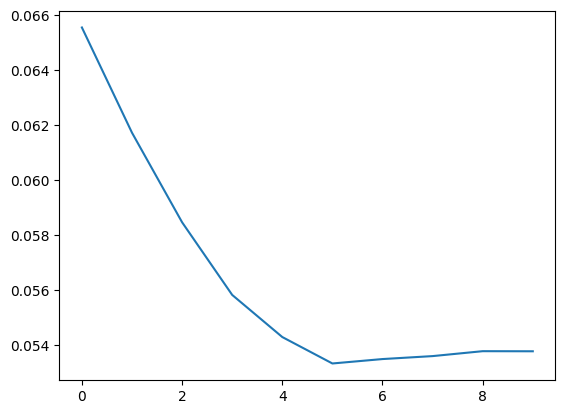

In [82]:
# ----- training loop -----
gru.train(); head.train()
loss_history = []
for epoch in range(10):
    train_loss = 0.0
    for xb, yb in train_loader:
        # forward (manual “forward”)
        out, h = gru(xb)               # out: (B, T, H), h: (1, B, H)
        feat = out[:, -1, :]           # OR: h[-1]  (both are (B, H))
        pred = torch.sigmoid(head(feat))  # keep in [0,1]

        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        
    loss_history.append(train_loss/len(train_loader.dataset))
    print(f"epoch {epoch+1:02d} | train MSE: {train_loss/len(train_loader.dataset):.6f}")
plt.plot(loss_history);

RMSE: 0.23506692 MAE: 0.2033291


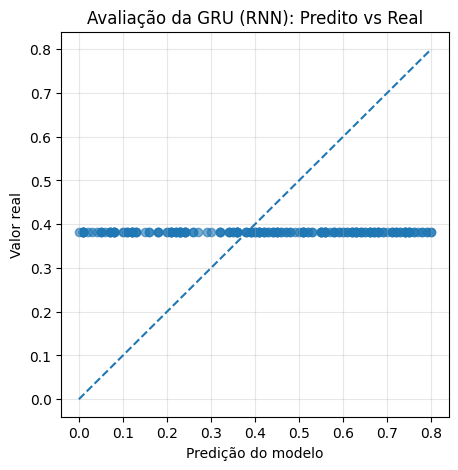

In [83]:
# ----- inference -----
gru.eval(); head.eval()
val_loss = 0
with torch.no_grad():
    for xb, yb in val_loader:
        out, h = gru(xb)
        feat = out[:, -1, :]
        y_pred = torch.sigmoid(head(feat))
        val_loss += criterion(y_pred, yb).item() * xb.size(0)
val_loss /= len(val_loader.dataset)

# RMSE, MAE
rmse = np.sqrt(np.mean((y_pred.squeeze().detach().cpu().numpy() - yval.reshape(-1,1))**2))
mae = np.mean(np.abs((y_pred.squeeze().detach().cpu().numpy() - yval.reshape(-1,1))))
print("RMSE:", rmse, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da GRU (RNN): Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

Horrível, RNN não funciona

## Random Forest

In [33]:
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.model_selection import train_test_split

n_init_points = 800
X = np.array(train_df.iloc[:,:800])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

[(1000, 800), (1000,), (800, 800), (200, 800), (800,), (200,)]


In [34]:
model = RFR(n_estimators=100, criterion='squared_error')
model.fit(Xtrain, ytrain)
y_pred, y_tr_pred = model.predict(Xval), model.predict(Xtrain)

RMSE: 0.09052436660921744 R²: 0.8497461080889994 MAE: 0.0700215


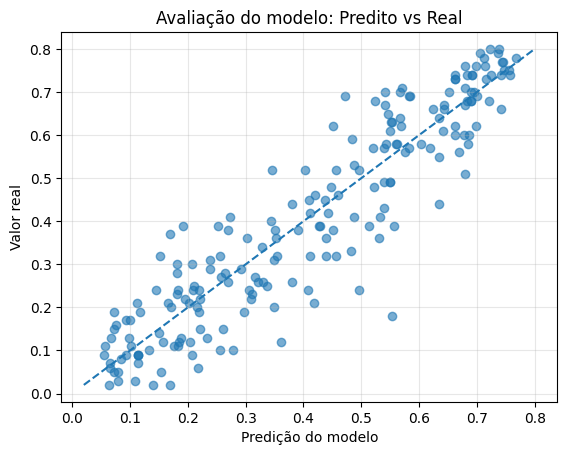

In [35]:
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
print("RMSE:", np.sqrt(mse), "R²:", 1-mse/np.std(yval)**2,"MAE:", mae)

# Gráfico de avaliação
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())

plt.scatter(y_pred, yval, alpha=0.6)
plt.plot([min_val, max_val], [min_val, max_val], '--')
plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação do modelo: Predito vs Real")
plt.grid(True, alpha=0.3)

plt.show()

Resultado fraco